In [1]:
import pandas as pd
import numpy as np
#from geopy.distance import geodesic
#from geopy.geocoders import Nominatim
from datetime import datetime, timedelta
#from sklearn.impute import KNNImputer, SimpleImputer

In [2]:
df_AfterFirstFilling = pd.read_csv("First filling.csv")

In [3]:
df_AfterFirstFilling.head()

,Unnamed: 0,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,0,2008-12-01,Albury,13.400000,22.900000,0.600000,6.828235,8.66625,W,44.000000,...,71.000000,22.000000,1007.7,1007.1,8.00,4.789474,16.900000,21.800000,No,No
1,1,2008-12-02,Albury,7.400000,32.600000,0.000000,NaN,NaN,WNW,59.000000,...,44.000000,25.000000,NaN,NaN,NaN,NaN,17.200000,24.300000,No,No
2,2,2008-12-03,Albury,12.900000,25.700000,0.000000,NaN,NaN,WSW,46.000000,...,38.000000,30.000000,NaN,NaN,3.00,4.000000,21.000000,23.200000,No,No
3,3,2008-12-04,Albury,9.200000,28.000000,0.000000,NaN,NaN,NE,43.628141,...,45.000000,16.000000,1017.6,1012.8,NaN,NaN,18.100000,26.500000,No,No
4,4,2008-12-05,Albury,15.154894,25.785654,1.936709,6.828235,8.66625,W,43.726775,...,61.722944,47.689362,1010.8,1006.0,4.92,4.801102,20.180519,24.071064,No,No


In [4]:
df_AfterFirstFilling = df_AfterFirstFilling.drop('Unnamed: 0', axis = 1)

In [5]:
df_AfterFirstFilling.head()

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2008-12-01,Albury,13.400000,22.900000,0.600000,6.828235,8.66625,W,44.000000,W,...,71.000000,22.000000,1007.7,1007.1,8.00,4.789474,16.900000,21.800000,No,No
1,2008-12-02,Albury,7.400000,32.600000,0.000000,NaN,NaN,WNW,59.000000,NNW,...,44.000000,25.000000,NaN,NaN,NaN,NaN,17.200000,24.300000,No,No
2,2008-12-03,Albury,12.900000,25.700000,0.000000,NaN,NaN,WSW,46.000000,W,...,38.000000,30.000000,NaN,NaN,3.00,4.000000,21.000000,23.200000,No,No
3,2008-12-04,Albury,9.200000,28.000000,0.000000,NaN,NaN,NE,43.628141,SE,...,45.000000,16.000000,1017.6,1012.8,NaN,NaN,18.100000,26.500000,No,No
4,2008-12-05,Albury,15.154894,25.785654,1.936709,6.828235,8.66625,W,43.726775,ENE,...,61.722944,47.689362,1010.8,1006.0,4.92,4.801102,20.180519,24.071064,No,No


In [7]:
df_AfterFirstFilling.dtypes

Date              object
Location          object
MinTemp          float64
MaxTemp          float64
Rainfall         float64
Evaporation      float64
Sunshine         float64
WindGustDir       object
WindGustSpeed    float64
WindDir9am        object
WindDir3pm        object
WindSpeed9am     float64
WindSpeed3pm     float64
Humidity9am      float64
Humidity3pm      float64
Pressure9am      float64
Pressure3pm      float64
Cloud9am         float64
Cloud3pm         float64
Temp9am          float64
Temp3pm          float64
RainToday         object
RainTomorrow      object
dtype: object

In [14]:
df_AfterFirstFilling.to_csv("First filling new.csv")

In [9]:
categorical_cols = ['WindGustDir', 'WindDir9am', 'WindDir3pm', 'RainToday', 'RainTomorrow']
non_imputed_cols = ['Date', 'Location']
numeric_cols = [col for col in df_AfterFirstFilling.columns if col not in categorical_cols + non_imputed_cols]
numeric_cols

['MinTemp',
 'MaxTemp',
 'Rainfall',
 'Evaporation',
 'Sunshine',
 'WindGustSpeed',
 'WindSpeed9am',
 'WindSpeed3pm',
 'Humidity9am',
 'Humidity3pm',
 'Pressure9am',
 'Pressure3pm',
 'Cloud9am',
 'Cloud3pm',
 'Temp9am',
 'Temp3pm']

In [21]:
# Store imputed dataframes for each location
imputed_dfs = []

In [13]:
# Loop through each location and apply KNNImputer to numeric columns
for location, group in df_AfterFirstFilling.groupby('Location'):
    numeric_data = group[numeric_cols]
    
    imputer = KNNImputer(n_neighbors=5)
    imputed_numeric = imputer.fit_transform(numeric_data)
    
    # Restore as DataFrame
    numeric_imputed_df = pd.DataFrame(imputed_numeric, columns=numeric_cols, index=group.index)

    # Add back categorical and non-imputed columns
    for col in categorical_cols + non_imputed_cols:
        numeric_imputed_df[col] = group[col]
    
    imputed_dfs.append(numeric_imputed_df)

ValueError: Shape of passed values is (3193, 14), indices imply (3193, 16)

In [15]:
# Find locations where one or more numeric columns are entirely missing
locations_to_drop = []

for location, group in df_AfterFirstFilling.groupby('Location'):
    all_nan = group[numeric_cols].isnull().all()
    if all_nan.any():
        locations_to_drop.append(location)

print(locations_to_drop)

['Adelaide', 'Albany', 'GoldCoast', 'Katherine', 'Launceston', 'Pearce RAAF', 'Salmon Gums', 'Uluru', 'Walpole', 'Witchcliffe']


In [16]:
# Drop those locations from the DataFrame
df_filtered = df_AfterFirstFilling[~df_AfterFirstFilling['Location'].isin(locations_to_drop)]
df_filtered.isnull().sum().sum()

232467

In [17]:
df_AfterFirstFilling.size

3345580

In [18]:
df_filtered.size

2713218

In [19]:
# Find locations where one or more categorical columns are entirely missing
locations_to_drop_categorical = []

for location, group in df_AfterFirstFilling.groupby('Location'):
    all_nan_categorical = group[categorical_cols].isnull().all()
    if all_nan_categorical.any():
        locations_to_drop_categorical.append(location)

print(locations_to_drop_categorical)

['Albany']


In [20]:
# Save filtered dataset
df_filtered.to_csv("filtered_weatherAUS_afterFirstFilling.csv", index=False)

In [ ]:
# Store imputed dataframes for each location
imputed_dfs = []

In [22]:
# Loop through each location and apply KNNImputer to numeric columns
for location, group in df_filtered.groupby('Location'):
    numeric_data = group[numeric_cols]
    
    imputer = KNNImputer(n_neighbors=5)
    imputed_numeric = imputer.fit_transform(numeric_data)
    
    # Restore as DataFrame
    numeric_imputed_df = pd.DataFrame(imputed_numeric, columns=numeric_cols, index=group.index)

    # Add back categorical and non-imputed columns
    for col in categorical_cols + non_imputed_cols:
        numeric_imputed_df[col] = group[col]
    
    imputed_dfs.append(numeric_imputed_df)

In [23]:
# 4. Combine all location-wise imputed dataframes
df_imputed = pd.concat(imputed_dfs).sort_index()

In [24]:
df_imputed

,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,...,Cloud3pm,Temp9am,Temp3pm,WindGustDir,WindDir9am,WindDir3pm,RainToday,RainTomorrow,Date,Location
0,13.400000,22.900000,0.600000,6.828235,8.666250,44.000000,20.000000,24.000000,71.000000,22.000000,...,4.789474,16.900000,21.800000,W,W,WNW,No,No,2008-12-01,Albury
1,7.400000,32.600000,0.000000,5.794592,9.464265,59.000000,4.000000,22.000000,44.000000,25.000000,...,2.489113,17.200000,24.300000,WNW,NNW,WSW,No,No,2008-12-02,Albury
2,12.900000,25.700000,0.000000,5.760000,9.140000,46.000000,19.000000,26.000000,38.000000,30.000000,...,4.000000,21.000000,23.200000,WSW,W,WSW,No,No,2008-12-03,Albury
3,9.200000,28.000000,0.000000,5.984526,6.553699,43.628141,11.000000,9.000000,45.000000,16.000000,...,4.366356,18.100000,26.500000,NE,SE,E,No,No,2008-12-04,Albury
4,15.154894,25.785654,1.936709,6.828235,8.666250,43.726775,14.515152,21.195745,61.722944,47.689362,...,4.801102,20.180519,24.071064,W,ENE,NW,No,No,2008-12-05,Albury
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
142299,21.200000,32.600000,0.000000,7.600000,8.600000,37.000000,13.000000,11.000000,56.000000,28.000000,...,0.000000,24.800000,32.000000,E,SE,SE,No,No,2017-06-21,Darwin
142300,20.700000,32.800000,0.000000,5.600000,11.000000,33.000000,17.000000,11.000000,46.000000,23.000000,...,0.000000,24.800000,32.100000,E,E,W,No,No,2017-06-22,Darwin
142301,19.500000,31.800000,0.000000,6.200000,10.600000,26.000000,9.000000,17.000000,62.000000,58.000000,...,1.000000,24.800000,29.200000,ESE,SE,NNW,No,No,2017-06-23,Darwin
142302,20.200000,31.700000,0.000000,5.600000,10.700000,30.000000,15.000000,7.000000,73.000000,32.000000,...,5.000000,25.400000,31.000000,ENE,ENE,NNW,No,No,2017-06-24,Darwin


In [25]:
df_imputed.isnull().sum().sum()

23872

In [26]:
total_nulls_in_categorical = df_imputed[categorical_cols].isnull().sum().sum()
total_nulls_in_categorical

23872

In [27]:
# Container for location-wise DataFrames
imputed_location_dfs = []

# Loop through each location group
for location, group in df_imputed.groupby('Location'):
    group_copy = group.copy()
    
    # Apply most_frequent imputation on categorical columns
    imputer = SimpleImputer(strategy='most_frequent')
    imputed_array = imputer.fit_transform(group_copy[categorical_cols])
    
    # Convert result back to DataFrame
    imputed_df = pd.DataFrame(imputed_array, columns=categorical_cols, index=group_copy.index)
    
    # Replace original categorical columns with imputed ones
    group_copy[categorical_cols] = imputed_df
    
    # Add to list
    imputed_location_dfs.append(group_copy)

# Combine all locations back together
df_categorical_imputed = pd.concat(imputed_location_dfs).sort_index()
df_categorical_imputed

,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,...,Cloud3pm,Temp9am,Temp3pm,WindGustDir,WindDir9am,WindDir3pm,RainToday,RainTomorrow,Date,Location
0,13.400000,22.900000,0.600000,6.828235,8.666250,44.000000,20.000000,24.000000,71.000000,22.000000,...,4.789474,16.900000,21.800000,W,W,WNW,No,No,2008-12-01,Albury
1,7.400000,32.600000,0.000000,5.794592,9.464265,59.000000,4.000000,22.000000,44.000000,25.000000,...,2.489113,17.200000,24.300000,WNW,NNW,WSW,No,No,2008-12-02,Albury
2,12.900000,25.700000,0.000000,5.760000,9.140000,46.000000,19.000000,26.000000,38.000000,30.000000,...,4.000000,21.000000,23.200000,WSW,W,WSW,No,No,2008-12-03,Albury
3,9.200000,28.000000,0.000000,5.984526,6.553699,43.628141,11.000000,9.000000,45.000000,16.000000,...,4.366356,18.100000,26.500000,NE,SE,E,No,No,2008-12-04,Albury
4,15.154894,25.785654,1.936709,6.828235,8.666250,43.726775,14.515152,21.195745,61.722944,47.689362,...,4.801102,20.180519,24.071064,W,ENE,NW,No,No,2008-12-05,Albury
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
142299,21.200000,32.600000,0.000000,7.600000,8.600000,37.000000,13.000000,11.000000,56.000000,28.000000,...,0.000000,24.800000,32.000000,E,SE,SE,No,No,2017-06-21,Darwin
142300,20.700000,32.800000,0.000000,5.600000,11.000000,33.000000,17.000000,11.000000,46.000000,23.000000,...,0.000000,24.800000,32.100000,E,E,W,No,No,2017-06-22,Darwin
142301,19.500000,31.800000,0.000000,6.200000,10.600000,26.000000,9.000000,17.000000,62.000000,58.000000,...,1.000000,24.800000,29.200000,ESE,SE,NNW,No,No,2017-06-23,Darwin
142302,20.200000,31.700000,0.000000,5.600000,10.700000,30.000000,15.000000,7.000000,73.000000,32.000000,...,5.000000,25.400000,31.000000,ENE,ENE,NNW,No,No,2017-06-24,Darwin


In [28]:
df_categorical_imputed.isnull().sum().sum()

0

In [29]:
df_categorical_imputed.to_csv("categorical_imputed_per_location.csv", index=False)

In [30]:
#shift backwards for predicting latter rain
df_categorical_imputed['Rainfall_next_day'] = df_categorical_imputed['Rainfall'].shift(-1)

In [32]:
#slice of new dataframe
dfFilledNew = df_categorical_imputed[['Date', 'Rainfall', 'Rainfall_next_day']]
dfFilledNew.iloc[0:10, :]

,Date,Rainfall,Rainfall_next_day
0,2008-12-01,0.600000,0.000000
1,2008-12-02,0.000000,0.000000
2,2008-12-03,0.000000,0.000000
3,2008-12-04,0.000000,1.936709
4,2008-12-05,1.936709,0.200000
5,2008-12-06,0.200000,0.000000
6,2008-12-07,0.000000,0.000000
7,2008-12-08,0.000000,0.000000
8,2008-12-09,0.000000,1.400000
9,2008-12-10,1.400000,0.000000


In [33]:
#dropped rain tomorrow. Because in reality, this would'nt be known
df_categorical_imputed.drop('RainTomorrow', inplace = True, axis=1)
#delete last row (no next day rain)
df_categorical_imputed = df_categorical_imputed[:-1]

In [34]:
categorical_cols = ['Location', 'WindGustDir', 'WindDir9am', 'WindDir3pm', 'RainToday']

In [35]:
categorical_cols

['Location', 'WindGustDir', 'WindDir9am', 'WindDir3pm', 'RainToday']

In [36]:
df_categorical_imputed['WindGustDir'].unique()

array(['W', 'WNW', 'WSW', 'NE', 'NNW', 'N', 'NNE', 'SW', 'ENE', 'SSE',
       'S', 'NW', 'E', 'SE', 'ESE', 'SSW'], dtype=object)

In [37]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

In [38]:
windGustDirHead = df_categorical_imputed['WindGustDir'].head()

In [39]:
windGustDirHead

0      W
1    WNW
2    WSW
3     NE
4      W
Name: WindGustDir, dtype: object

In [40]:
oneHotEncode = OneHotEncoder()

In [41]:
dfWindGustDirHead = pd.DataFrame(windGustDirHead)

In [42]:
windGustDirHead = oneHotEncode.fit_transform(dfWindGustDirHead)

In [44]:
windGustDirHead

<5x4 sparse matrix of type '<class 'numpy.float64'>'
	with 5 stored elements in Compressed Sparse Row format>

In [45]:
windGustDirHead.toarray()

array([[0., 1., 0., 0.],
       [0., 0., 1., 0.],
       [0., 0., 0., 1.],
       [1., 0., 0., 0.],
       [0., 1., 0., 0.]])

In [46]:
print(windGustDirHead)

  (0, 1)	1.0
  (1, 2)	1.0
  (2, 3)	1.0
  (3, 0)	1.0
  (4, 1)	1.0


In [48]:
oneHotEncode.inverse_transform(windGustDirHead)

array([['W'],
       ['WNW'],
       ['WSW'],
       ['NE'],
       ['W']], dtype=object)

In [64]:
df_categorical_imputed = pd.read_csv("categorical_imputed_per_location.csv", parse_dates=['Date'])

In [67]:
#shift backwards for predicting latter rain
df_categorical_imputed['Rainfall_next_day'] = df_categorical_imputed['Rainfall'].shift(-1)

In [68]:
#slice of new dataframe
dfFilledNew = df_categorical_imputed[['Date', 'Rainfall', 'Rainfall_next_day']]
dfFilledNew.iloc[0:10, :]

,Date,Rainfall,Rainfall_next_day
0,2008-12-01,0.600000,0.000000
1,2008-12-02,0.000000,0.000000
2,2008-12-03,0.000000,0.000000
3,2008-12-04,0.000000,1.936709
4,2008-12-05,1.936709,0.200000
5,2008-12-06,0.200000,0.000000
6,2008-12-07,0.000000,0.000000
7,2008-12-08,0.000000,0.000000
8,2008-12-09,0.000000,1.400000
9,2008-12-10,1.400000,0.000000


In [69]:
#dropped rain tomorrow. Because in reality, this would'nt be known
df_categorical_imputed.drop('RainTomorrow', inplace = True, axis=1)
#delete last row (no next day rain)
df_categorical_imputed = df_categorical_imputed[:-1]

In [106]:
dfFilled = df_categorical_imputed.copy()

In [107]:
dfFilled

,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,...,Cloud3pm,Temp9am,Temp3pm,WindGustDir,WindDir9am,WindDir3pm,RainToday,Date,Location,Rainfall_next_day
0,13.400000,22.900000,0.600000,6.828235,8.666250,44.000000,20.000000,24.000000,71.000000,22.000000,...,4.789474,16.900000,21.800000,W,W,WNW,No,2008-12-01,Albury,0.000000
1,7.400000,32.600000,0.000000,5.794592,9.464265,59.000000,4.000000,22.000000,44.000000,25.000000,...,2.489113,17.200000,24.300000,WNW,NNW,WSW,No,2008-12-02,Albury,0.000000
2,12.900000,25.700000,0.000000,5.760000,9.140000,46.000000,19.000000,26.000000,38.000000,30.000000,...,4.000000,21.000000,23.200000,WSW,W,WSW,No,2008-12-03,Albury,0.000000
3,9.200000,28.000000,0.000000,5.984526,6.553699,43.628141,11.000000,9.000000,45.000000,16.000000,...,4.366356,18.100000,26.500000,NE,SE,E,No,2008-12-04,Albury,1.936709
4,15.154894,25.785654,1.936709,6.828235,8.666250,43.726775,14.515152,21.195745,61.722944,47.689362,...,4.801102,20.180519,24.071064,W,ENE,NW,No,2008-12-05,Albury,0.200000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
117960,19.300000,33.400000,0.000000,6.000000,11.000000,35.000000,9.000000,20.000000,63.000000,32.000000,...,1.000000,24.500000,32.300000,ENE,SE,NE,No,2017-06-20,Darwin,0.000000
117961,21.200000,32.600000,0.000000,7.600000,8.600000,37.000000,13.000000,11.000000,56.000000,28.000000,...,0.000000,24.800000,32.000000,E,SE,SE,No,2017-06-21,Darwin,0.000000
117962,20.700000,32.800000,0.000000,5.600000,11.000000,33.000000,17.000000,11.000000,46.000000,23.000000,...,0.000000,24.800000,32.100000,E,E,W,No,2017-06-22,Darwin,0.000000
117963,19.500000,31.800000,0.000000,6.200000,10.600000,26.000000,9.000000,17.000000,62.000000,58.000000,...,1.000000,24.800000,29.200000,ESE,SE,NNW,No,2017-06-23,Darwin,0.000000


In [91]:
windGustDir = dfFilled['WindGustDir']

In [92]:
dfWindGustDir = pd.DataFrame(windGustDir)

In [93]:
windGustDir

0           W
1         WNW
2         WSW
3          NE
4           W
         ... 
117960    ENE
117961      E
117962      E
117963    ESE
117964    ENE
Name: WindGustDir, Length: 117965, dtype: object

In [94]:
windGustDir = oneHotEncode.fit_transform(dfWindGustDir)

In [95]:
windGustDir

<117965x16 sparse matrix of type '<class 'numpy.float64'>'
	with 117965 stored elements in Compressed Sparse Row format>

In [96]:
windGustDir.dtype

dtype('float64')

In [101]:
print(windGustDir)

  (0, 13)	1.0
  (1, 14)	1.0
  (2, 15)	1.0
  (3, 4)	1.0
  (4, 13)	1.0
  (5, 14)	1.0
  (6, 14)	1.0
  (7, 13)	1.0
  (8, 6)	1.0
  (9, 13)	1.0
  (10, 3)	1.0
  (11, 5)	1.0
  (12, 13)	1.0
  (13, 12)	1.0
  (14, 1)	1.0
  (15, 14)	1.0
  (16, 1)	1.0
  (17, 13)	1.0
  (18, 10)	1.0
  (19, 14)	1.0
  (20, 8)	1.0
  (21, 4)	1.0
  (22, 14)	1.0
  (23, 3)	1.0
  (24, 13)	1.0
  :	:
  (117940, 2)	1.0
  (117941, 2)	1.0
  (117942, 2)	1.0
  (117943, 2)	1.0
  (117944, 0)	1.0
  (117945, 0)	1.0
  (117946, 0)	1.0
  (117947, 2)	1.0
  (117948, 0)	1.0
  (117949, 0)	1.0
  (117950, 2)	1.0
  (117951, 0)	1.0
  (117952, 2)	1.0
  (117953, 2)	1.0
  (117954, 0)	1.0
  (117955, 0)	1.0
  (117956, 2)	1.0
  (117957, 0)	1.0
  (117958, 0)	1.0
  (117959, 0)	1.0
  (117960, 1)	1.0
  (117961, 0)	1.0
  (117962, 0)	1.0
  (117963, 2)	1.0
  (117964, 1)	1.0


In [102]:
windGustDirArray = windGustDir.toarray()

In [103]:
windGustDirArray

array([[0., 0., 0., ..., 1., 0., 0.],
       [0., 0., 0., ..., 0., 1., 0.],
       [0., 0., 0., ..., 0., 0., 1.],
       ...,
       [1., 0., 0., ..., 0., 0., 0.],
       [0., 0., 1., ..., 0., 0., 0.],
       [0., 1., 0., ..., 0., 0., 0.]])

In [108]:
# Begin True One-Hot Encoding

categorical_to_oneHot_encode = ['Location', 'WindGustDir', 'WindDir9am', 'WindDir3pm']

In [110]:
df_oneHot_encoded = pd.get_dummies(dfFilled, columns=categorical_to_oneHot_encode)
df_oneHot_encoded.columns

Index(['MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation', 'Sunshine',
       'WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am',
       'Humidity3pm',
       ...
       'WindDir3pm_NNW', 'WindDir3pm_NW', 'WindDir3pm_S', 'WindDir3pm_SE',
       'WindDir3pm_SSE', 'WindDir3pm_SSW', 'WindDir3pm_SW', 'WindDir3pm_W',
       'WindDir3pm_WNW', 'WindDir3pm_WSW'],
      dtype='object', length=106)

In [111]:
for col in df_oneHot_encoded.columns:
    print(col)

MinTemp
MaxTemp
Rainfall
Evaporation
Sunshine
WindGustSpeed
WindSpeed9am
WindSpeed3pm
Humidity9am
Humidity3pm
Pressure9am
Pressure3pm
Cloud9am
Cloud3pm
Temp9am
Temp3pm
RainToday
Date
Rainfall_next_day
Location_Albury
Location_Alice Springs
Location_Badgerys Creek
Location_Ballarat
Location_Bendigo
Location_Brisbane
Location_Cairns
Location_Canberra
Location_Cobar
Location_Coffs Harbour
Location_Dartmoor
Location_Darwin
Location_Hobart
Location_Melbourne
Location_Melbourne Airport
Location_Mildura
Location_Moree
Location_Mount Gambier
Location_Mount Ginini
Location_Newcastle
Location_Nhil
Location_Norah Head
Location_Norfolk Island
Location_Nuriootpa
Location_Penrith
Location_Perth
Location_Perth Airport
Location_Portland
Location_Richmond
Location_Sale
Location_Sydney
Location_Sydney Airport
Location_Townsville
Location_Tuggeranong
Location_Wagga Wagga
Location_Watsonia
Location_Williamtown
Location_Wollongong
Location_Woomera
WindGustDir_E
WindGustDir_ENE
WindGustDir_ESE
WindGustDir_N

In [112]:
# Do label encoding
labelEncode = LabelEncoder()

df_categorical_encoded = df_oneHot_encoded.copy()
df_categorical_encoded["RainToday"] = labelEncode.fit_transform(df_categorical_encoded["RainToday"])

In [113]:
# check if it encoded correctly
df_categorical_encoded[df_categorical_encoded["RainToday"] == 1]

,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,...,WindDir3pm_NNW,WindDir3pm_NW,WindDir3pm_S,WindDir3pm_SE,WindDir3pm_SSE,WindDir3pm_SSW,WindDir3pm_SW,WindDir3pm_W,WindDir3pm_WNW,WindDir3pm_WSW
9,13.10000,30.100000,1.400000,6.844257,8.692837,28.000000,15.000000,11.000000,58.000000,27.000000,...,0,0,0,0,1,0,0,0,0,0
11,15.90000,21.700000,2.200000,6.960000,5.640000,43.795753,15.000000,13.000000,89.000000,91.000000,...,0,0,0,0,0,0,0,0,0,0
12,15.90000,18.600000,15.600000,7.503322,11.600000,61.000000,28.000000,28.000000,76.000000,93.000000,...,1,0,0,0,0,0,0,0,0,0
13,12.60000,21.000000,3.600000,6.732048,8.533286,44.000000,24.000000,20.000000,65.000000,43.000000,...,0,0,0,0,0,1,0,0,0,0
17,15.12542,25.818594,1.881495,6.732048,8.533286,43.815976,14.156566,21.204783,62.128955,48.310757,...,0,0,0,0,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
117891,18.00000,27.900000,65.800000,7.920000,1.000000,41.000000,13.000000,20.000000,98.000000,78.000000,...,0,0,0,0,0,0,0,0,0,0
117892,21.60000,31.700000,3.400000,2.000000,10.000000,37.000000,13.000000,13.000000,78.000000,56.000000,...,0,0,0,0,0,0,0,0,0,0
117896,25.60000,33.000000,7.200000,5.600000,7.900000,39.000000,19.000000,20.000000,77.000000,55.000000,...,0,0,0,0,0,0,0,0,0,0
117899,24.70000,33.700000,1.800000,6.200000,9.700000,33.000000,9.000000,17.000000,80.000000,53.000000,...,0,0,0,0,0,0,0,0,0,0


In [114]:
df_categorical_encoded.to_csv("categorical_encoded.csv", index=False)

In [2]:
df_categorical_encoded = pd.read_csv("categorical_encoded.csv", parse_dates=['Date'])

In [38]:
#shift backwards for predicting latter rain
df_categorical_encoded['Rainfall_next_30_days'] = df_categorical_encoded['Rainfall'].shift(-30)

<ipython-input-38-3bcda971a9cb>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_categorical_encoded['Rainfall_next_30_days'] = df_categorical_encoded['Rainfall'].shift(-30)


In [39]:
#slice of new dataframe
dfFilledNew = df_categorical_encoded[['Date', 'Rainfall', 'Rainfall_next_30_days']]
dfFilledNew.iloc[0:35, :]

,Date,Rainfall,Rainfall_next_30_days
0,2008-12-01,0.600000,2.020815
1,2008-12-02,0.000000,0.000000
2,2008-12-03,0.000000,0.000000
3,2008-12-04,0.000000,0.000000
4,2008-12-05,1.936709,0.000000
5,2008-12-06,0.200000,0.000000
6,2008-12-07,0.000000,0.000000
7,2008-12-08,0.000000,0.000000
8,2008-12-09,0.000000,0.000000
9,2008-12-10,1.400000,0.000000


In [40]:
df_categorical_encoded

,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,...,WindDir3pm_SE,WindDir3pm_SSE,WindDir3pm_SSW,WindDir3pm_SW,WindDir3pm_W,WindDir3pm_WNW,WindDir3pm_WSW,Rainfall_next_20_days,Rainfall_next_25_days,Rainfall_next_30_days
0,13.400000,22.900000,0.600000,6.828235,8.666250,44.000000,20.000000,24.000000,71.000000,22.000000,...,0,0,0,0,0,1,0,0.0,0.0,2.020815
1,7.400000,32.600000,0.000000,5.794592,9.464265,59.000000,4.000000,22.000000,44.000000,25.000000,...,0,0,0,0,0,0,1,0.0,0.0,0.000000
2,12.900000,25.700000,0.000000,5.760000,9.140000,46.000000,19.000000,26.000000,38.000000,30.000000,...,0,0,0,0,0,0,1,0.0,0.0,0.000000
3,9.200000,28.000000,0.000000,5.984526,6.553699,43.628141,11.000000,9.000000,45.000000,16.000000,...,0,0,0,0,0,0,0,0.0,0.0,0.000000
4,15.154894,25.785654,1.936709,6.828235,8.666250,43.726775,14.515152,21.195745,61.722944,47.689362,...,0,0,0,0,0,0,0,0.0,1.2,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
117915,23.100000,33.500000,0.000000,6.000000,11.200000,33.000000,11.000000,13.000000,68.000000,43.000000,...,0,0,0,0,0,0,0,0.0,0.2,NaN
117916,23.900000,33.700000,0.000000,6.200000,11.000000,39.000000,13.000000,17.000000,72.000000,34.000000,...,1,0,0,0,0,0,0,0.0,0.0,NaN
117917,22.400000,33.000000,0.000000,6.800000,10.700000,44.000000,13.000000,24.000000,57.000000,38.000000,...,0,0,0,0,0,0,0,0.0,0.0,NaN
117918,22.400000,33.200000,0.000000,6.800000,11.200000,46.000000,13.000000,20.000000,55.000000,26.000000,...,0,0,0,0,0,0,0,0.0,0.0,NaN


In [100]:
#df_categorical_encoded.drop('Rainfall_next_5_days', inplace = True, axis=1)
#df_categorical_encoded.drop('Rainfall_next_10_days', inplace = True, axis=1)
#df_categorical_encoded.drop('Rainfall_next_15_days', inplace = True, axis=1)

MemoryError: Unable to allocate 79.2 MiB for an array with shape (88, 117915) and data type int64

In [41]:
#delete last x row (no next day rain)
df_categorical_encoded = df_categorical_encoded[:-30]
df_categorical_encoded

,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,...,WindDir3pm_SE,WindDir3pm_SSE,WindDir3pm_SSW,WindDir3pm_SW,WindDir3pm_W,WindDir3pm_WNW,WindDir3pm_WSW,Rainfall_next_20_days,Rainfall_next_25_days,Rainfall_next_30_days
0,13.400000,22.900000,0.600000,6.828235,8.666250,44.000000,20.000000,24.000000,71.000000,22.000000,...,0,0,0,0,0,1,0,0.0,0.0,2.020815
1,7.400000,32.600000,0.000000,5.794592,9.464265,59.000000,4.000000,22.000000,44.000000,25.000000,...,0,0,0,0,0,0,1,0.0,0.0,0.000000
2,12.900000,25.700000,0.000000,5.760000,9.140000,46.000000,19.000000,26.000000,38.000000,30.000000,...,0,0,0,0,0,0,1,0.0,0.0,0.000000
3,9.200000,28.000000,0.000000,5.984526,6.553699,43.628141,11.000000,9.000000,45.000000,16.000000,...,0,0,0,0,0,0,0,0.0,0.0,0.000000
4,15.154894,25.785654,1.936709,6.828235,8.666250,43.726775,14.515152,21.195745,61.722944,47.689362,...,0,0,0,0,0,0,0,0.0,1.2,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
117885,23.600000,33.600000,24.600000,6.600000,8.500000,46.000000,7.000000,13.000000,83.000000,59.000000,...,0,0,0,0,0,0,0,0.0,0.0,0.000000
117886,24.100000,33.300000,27.600000,7.600000,7.200000,56.000000,6.000000,20.000000,81.000000,53.000000,...,0,0,0,0,0,0,0,0.2,0.0,0.000000
117887,25.900000,34.200000,0.000000,5.200000,9.100000,33.000000,11.000000,11.000000,75.000000,40.000000,...,0,0,0,0,0,0,0,3.4,0.0,0.000000
117888,25.500000,33.600000,0.000000,5.400000,6.400000,43.000000,17.000000,24.000000,65.000000,57.000000,...,0,0,0,0,0,0,0,0.0,0.0,0.000000


In [42]:
#identifying related and unrelated column
cor = df_categorical_encoded.corr()
#plt.figure(figsize = (20,12))
#sns.heatmap(cor, annot=True)

In [43]:
related = cor['Rainfall_next_30_days'].sort_values(ascending = False)
related

Rainfall_next_30_days     1.000000
MinTemp                   0.076808
Humidity3pm               0.066069
Temp9am                   0.063115
Location_Cairns           0.060690
                            ...   
Location_Mildura         -0.026669
Location_Alice Springs   -0.028833
Location_Woomera         -0.035582
Pressure9am              -0.037695
Pressure3pm              -0.038209
Name: Rainfall_next_30_days, Length: 108, dtype: float64

In [119]:
x = []
for i in range (len(related)):
    if related[i]>0:
        x.append(related.index[i])
        
x

['Rainfall_next_day',
 'Rainfall',
 'Humidity3pm',
 'RainToday',
 'Humidity9am',
 'WindGustSpeed',
 'MinTemp',
 'Cloud3pm',
 'Cloud9am',
 'Location_Cairns',
 'WindSpeed9am',
 'Temp9am',
 'Location_Darwin',
 'Location_Coffs Harbour',
 'WindSpeed3pm',
 'Location_Williamtown',
 'Location_Wollongong',
 'Location_Townsville',
 'Location_Norah Head',
 'Location_Sydney',
 'Location_Brisbane',
 'Location_Mount Ginini',
 'WindGustDir_S',
 'Location_Norfolk Island',
 'Location_Newcastle',
 'WindDir9am_NNE',
 'WindDir3pm_NNE',
 'Location_Sydney Airport',
 'WindDir9am_SW',
 'WindGustDir_NNE',
 'WindDir3pm_SE',
 'WindDir3pm_ENE',
 'WindGustDir_SSE',
 'WindDir9am_S',
 'WindDir3pm_N',
 'WindDir3pm_S',
 'WindGustDir_E',
 'WindGustDir_N',
 'WindDir3pm_NNW',
 'WindGustDir_SE',
 'WindDir3pm_SSW',
 'WindGustDir_NW',
 'WindDir9am_N',
 'WindDir3pm_SSE',
 'WindDir9am_NNW',
 'Location_Portland',
 'WindGustDir_NE',
 'WindDir3pm_E',
 'WindDir3pm_ESE',
 'WindDir3pm_NE']

In [44]:
x = []
for i in range (len(related)):
    if related[i]>=0.05:
        x.append(related.index[i])
        
x

['Rainfall_next_30_days',
 'MinTemp',
 'Humidity3pm',
 'Temp9am',
 'Location_Cairns',
 'Rainfall_next_25_days',
 'Rainfall_next_20_days',
 'Location_Darwin']

In [45]:
x = df_categorical_encoded[x]
#x.drop('Rainfall_next_day', inplace = True, axis=1)
#x.drop('Rainfall_next_5_days', inplace = True, axis=1)
#x.drop('Rainfall_next_10_days', inplace = True, axis=1)
#x.drop('Rainfall_next_15_days', inplace = True, axis=1)
x.drop('Rainfall_next_20_days', inplace = True, axis=1)
x.drop('Rainfall_next_25_days', inplace = True, axis=1)
x.drop('Rainfall_next_30_days', inplace = True, axis=1)
x

C:\ProgramData\Anaconda3\lib\site-packages\pandas\core\frame.py:4163: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  return super().drop(


,MinTemp,Humidity3pm,Temp9am,Location_Cairns,Location_Darwin
0,13.400000,22.000000,16.900000,0,0
1,7.400000,25.000000,17.200000,0,0
2,12.900000,30.000000,21.000000,0,0
3,9.200000,16.000000,18.100000,0,0
4,15.154894,47.689362,20.180519,0,0
...,...,...,...,...,...
117885,23.600000,59.000000,26.800000,0,1
117886,24.100000,53.000000,27.500000,0,1
117887,25.900000,40.000000,29.400000,0,1
117888,25.500000,57.000000,28.000000,0,1


In [46]:
y = df_categorical_encoded['Rainfall_next_30_days']
y

0         2.020815
1         0.000000
2         0.000000
3         0.000000
4         0.000000
            ...   
117885    0.000000
117886    0.000000
117887    0.000000
117888    0.000000
117889    0.000000
Name: Rainfall_next_30_days, Length: 117890, dtype: float64

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt
#from sklearn.model_selection import train_test_split
#from sklearn.ensemble import RandomForestRegressor
#from sklearn.linear_model import LinearRegression
#import pmdarima as pm
#from sklearn.metrics import mean_absolute_error, mean_squared_error
from matplotlib import rcParams
#from sklearn.preprocessing import StandardScaler

In [47]:
X_train, X_test, y_train, y_test = train_test_split(x,y, test_size=0.2, shuffle=False)

In [48]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [49]:
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

LinearRegression()

In [50]:
y_pred = lr_model.predict(X_test_scaled)

In [51]:
lr_MAE = mean_absolute_error(y_test, y_pred)
print("Mean absolute error: ", lr_MAE)

Mean absolute error:  3.315965479412244


In [16]:
y_test.mean()

1.9063976603229886

In [52]:
lr_MSE = mean_squared_error(y_test, y_pred)
print("Mean squared error: ", lr_MSE)

Mean squared error:  56.12866725660442


In [53]:
lr_RMSE = np.sqrt(lr_MSE)
print("Root mean squared error: ", lr_RMSE)

Root mean squared error:  7.4919067837636915


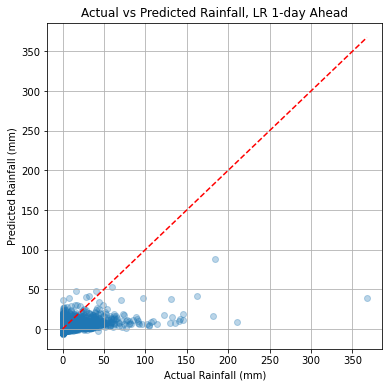

In [21]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, alpha=0.3)
plt.plot([0, y_test.max()], [0, y_test.max()], '--r')
plt.xlabel("Actual Rainfall (mm)")
plt.ylabel("Predicted Rainfall (mm)")
plt.title("Actual vs Predicted Rainfall, LR 1-day Ahead")
plt.grid(True)
plt.show()


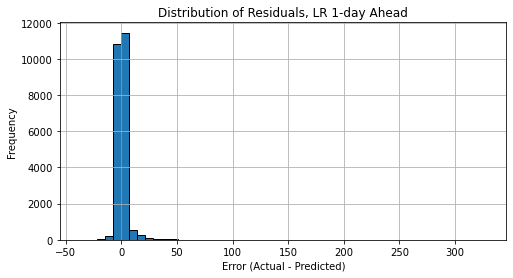

In [22]:
residuals = y_test - y_pred

plt.figure(figsize=(8, 4))
plt.hist(residuals, bins=50, edgecolor='k')
plt.title("Distribution of Residuals, LR 1-day Ahead")
plt.xlabel("Error (Actual - Predicted)")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()


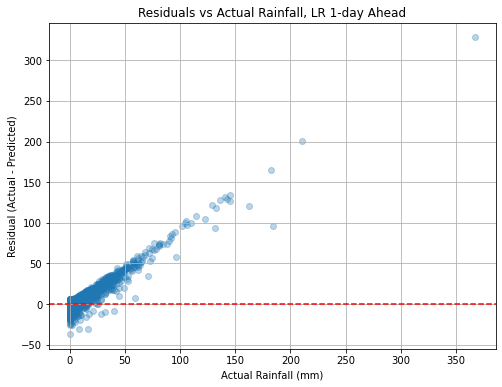

In [23]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, residuals, alpha=0.3)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Actual Rainfall (mm)")
plt.ylabel("Residual (Actual - Predicted)")
plt.title("Residuals vs Actual Rainfall, LR 1-day Ahead")
plt.grid(True)
plt.show()

In [24]:
# Extract one-hot encoded location columns
location_cols = [col for col in df_categorical_encoded.columns if col.startswith("Location_")]

In [25]:
# Recovered Location column
df_categorical_encoded['Location'] = df_categorical_encoded[location_cols].idxmax(axis=1).str.replace('Location_', '')

In [29]:
df_categorical_encoded

,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,...,WindDir3pm_NW,WindDir3pm_S,WindDir3pm_SE,WindDir3pm_SSE,WindDir3pm_SSW,WindDir3pm_SW,WindDir3pm_W,WindDir3pm_WNW,WindDir3pm_WSW,Location
0,13.400000,22.900000,0.600000,6.828235,8.666250,44.000000,20.000000,24.000000,71.000000,22.000000,...,0,0,0,0,0,0,0,1,0,Albury
1,7.400000,32.600000,0.000000,5.794592,9.464265,59.000000,4.000000,22.000000,44.000000,25.000000,...,0,0,0,0,0,0,0,0,1,Albury
2,12.900000,25.700000,0.000000,5.760000,9.140000,46.000000,19.000000,26.000000,38.000000,30.000000,...,0,0,0,0,0,0,0,0,1,Albury
3,9.200000,28.000000,0.000000,5.984526,6.553699,43.628141,11.000000,9.000000,45.000000,16.000000,...,0,0,0,0,0,0,0,0,0,Albury
4,15.154894,25.785654,1.936709,6.828235,8.666250,43.726775,14.515152,21.195745,61.722944,47.689362,...,1,0,0,0,0,0,0,0,0,Albury
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
117960,19.300000,33.400000,0.000000,6.000000,11.000000,35.000000,9.000000,20.000000,63.000000,32.000000,...,0,0,0,0,0,0,0,0,0,Darwin
117961,21.200000,32.600000,0.000000,7.600000,8.600000,37.000000,13.000000,11.000000,56.000000,28.000000,...,0,0,1,0,0,0,0,0,0,Darwin
117962,20.700000,32.800000,0.000000,5.600000,11.000000,33.000000,17.000000,11.000000,46.000000,23.000000,...,0,0,0,0,0,0,1,0,0,Darwin
117963,19.500000,31.800000,0.000000,6.200000,10.600000,26.000000,9.000000,17.000000,62.000000,58.000000,...,0,0,0,0,0,0,0,0,0,Darwin


In [37]:
X_test

,Rainfall,Humidity3pm,RainToday,Humidity9am,WindGustSpeed,MinTemp,Cloud3pm,Cloud9am
94372,0.0,36.0,0,56.0,39.0,8.4,1.0,2.0
94373,0.0,48.0,0,68.0,37.0,10.1,2.0,8.0
94374,0.0,31.0,0,60.0,33.0,10.3,1.0,1.0
94375,0.0,24.0,0,41.0,37.0,11.6,1.0,0.0
94376,0.0,21.0,0,49.0,35.0,11.3,2.0,1.0
...,...,...,...,...,...,...,...,...
117960,0.0,32.0,0,63.0,35.0,19.3,1.0,0.0
117961,0.0,28.0,0,56.0,37.0,21.2,0.0,7.0
117962,0.0,23.0,0,46.0,33.0,20.7,0.0,0.0
117963,0.0,58.0,0,62.0,26.0,19.5,1.0,1.0


In [30]:
# Select just the Location column
location_column = df_categorical_encoded.loc[X_test.index, 'Location']

In [31]:
# Merge with X_test
X_test_with_location = X_test.copy()
X_test_with_location['Location'] = location_column

In [32]:
# Add prediction results
X_test_with_location['Actual'] = y_test.values
X_test_with_location['Predicted'] = y_pred

In [33]:
X_test_with_location['Abs_Error'] = abs(X_test_with_location['Actual'] - X_test_with_location['Predicted'])

<AxesSubplot:title={'center':'MAE by Location, LR 1-day Ahead'}, xlabel='Location'>

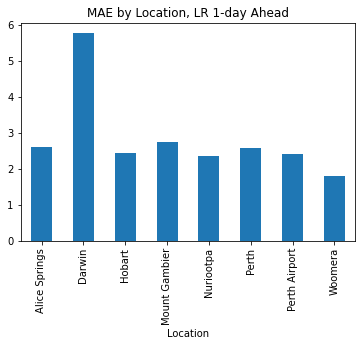

In [41]:
error_by_location = X_test_with_location.groupby('Location')['Abs_Error'].mean()
error_by_location.plot(kind='bar', title='MAE by Location, LR 1-day Ahead')

In [38]:
# Select just the Date column
date_column = df_categorical_encoded.loc[X_test.index, 'Date']

In [39]:
# Merge with X_test
X_test_with_date = X_test.copy()
X_test_with_date['Date'] = date_column

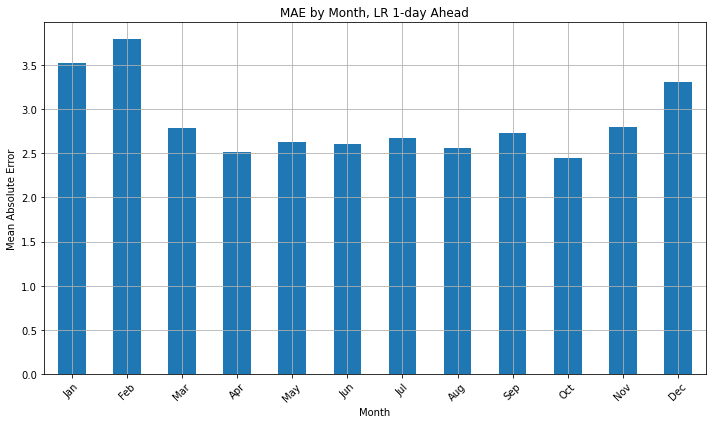

In [44]:
X_test_with_location['Month'] = pd.to_datetime(X_test_with_date['Date']).dt.month
monthly_error = X_test_with_location.groupby('Month')['Abs_Error'].mean()

# Plotting
ax = monthly_error.plot(kind='bar', figsize=(10, 6), title='MAE by Month, LR 1-day Ahead')
ax.set_xlabel("Month")
ax.set_ylabel("Mean Absolute Error")

# Replace x-tick labels with month names
ax.set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                    'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'], rotation=45)

plt.grid(True)
plt.tight_layout()
plt.show()

In [42]:
X_test_with_location

,Rainfall,Humidity3pm,RainToday,Humidity9am,WindGustSpeed,MinTemp,Cloud3pm,Cloud9am,Location,Actual,Predicted,Abs_Error,Month
94372,0.0,36.0,0,56.0,39.0,8.4,1.0,2.0,Mount Gambier,0.0,-0.555942,0.555942,12
94373,0.0,48.0,0,68.0,37.0,10.1,2.0,8.0,Mount Gambier,0.0,0.985460,0.985460,12
94374,0.0,31.0,0,60.0,33.0,10.3,1.0,1.0,Mount Gambier,0.0,-1.198930,1.198930,12
94375,0.0,24.0,0,41.0,37.0,11.6,1.0,0.0,Mount Gambier,0.0,-1.649265,1.649265,12
94376,0.0,21.0,0,49.0,35.0,11.3,2.0,1.0,Mount Gambier,0.0,-1.969276,1.969276,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
117960,0.0,32.0,0,63.0,35.0,19.3,1.0,0.0,Darwin,0.0,0.111578,0.111578,6
117961,0.0,28.0,0,56.0,37.0,21.2,0.0,7.0,Darwin,0.0,0.046110,0.046110,6
117962,0.0,23.0,0,46.0,33.0,20.7,0.0,0.0,Darwin,0.0,-0.950250,0.950250,6
117963,0.0,58.0,0,62.0,26.0,19.5,1.0,1.0,Darwin,0.0,2.205276,2.205276,6


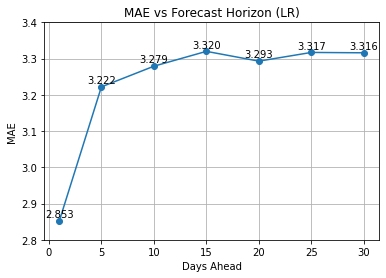

In [4]:
# Trend Over forecast horizon

# list of MAE per horizon
horizons = [1, 5, 10, 15, 20, 25, 30]
mae_per_horizon = [2.853, 3.222, 3.279, 3.320, 3.293, 3.317, 3.316]

plt.plot(horizons, mae_per_horizon, marker='o')
plt.title("MAE vs Forecast Horizon (LR)")
plt.xlabel("Days Ahead")
plt.ylabel("MAE")
plt.ylim(2.8, 3.4)
plt.grid(True)
for x, y in zip(horizons, mae_per_horizon):
    plt.text(x, y + 0.01, f"{y:.3f}", ha='center')
plt.show()


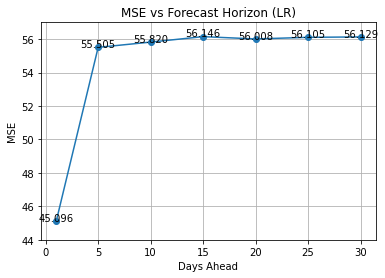

In [5]:
# Trend Over forecast horizon

# list of MSE per horizon
horizons = [1, 5, 10, 15, 20, 25, 30]
mse_per_horizon = [45.096, 55.505, 55.820, 56.146, 56.008, 56.105, 56.129]

plt.plot(horizons, mse_per_horizon, marker='o')
plt.title("MSE vs Forecast Horizon (LR)")
plt.xlabel("Days Ahead")
plt.ylabel("MSE")
plt.ylim(44, 57)
plt.grid(True)
for x, y in zip(horizons, mse_per_horizon):
    plt.text(x, y + 0.01, f"{y:.3f}", ha='center')
plt.show()


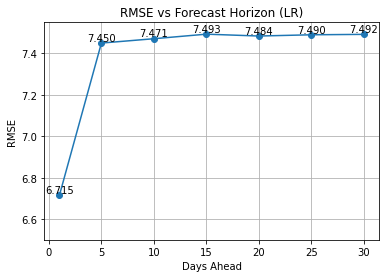

In [6]:
# Trend Over forecast horizon

# list of RMSE per horizon
horizons = [1, 5, 10, 15, 20, 25, 30]
rmse_per_horizon = [6.715, 7.450, 7.471, 7.493, 7.484, 7.490, 7.492]

plt.plot(horizons, rmse_per_horizon, marker='o')
plt.title("RMSE vs Forecast Horizon (LR)")
plt.xlabel("Days Ahead")
plt.ylabel("RMSE")
plt.ylim(6.5, 7.55)
plt.grid(True)
for x, y in zip(horizons, rmse_per_horizon):
    plt.text(x, y + 0.01, f"{y:.3f}", ha='center')
plt.show()


In [84]:
df_categorical_encoded = pd.read_csv("categorical_encoded.csv", parse_dates=['Date'])

ParserError: Error tokenizing data. C error: out of memory

In [9]:
# Extract one-hot encoded location columns
location_cols = [col for col in df_categorical_encoded.columns if col.startswith("Location_")]

In [10]:
# Recovered Location column
df_categorical_encoded['Location'] = df_categorical_encoded[location_cols].idxmax(axis=1).str.replace('Location_', '')

In [11]:
df_categorical_encoded

,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,...,WindDir3pm_NW,WindDir3pm_S,WindDir3pm_SE,WindDir3pm_SSE,WindDir3pm_SSW,WindDir3pm_SW,WindDir3pm_W,WindDir3pm_WNW,WindDir3pm_WSW,Location
0,13.400000,22.900000,0.600000,6.828235,8.666250,44.000000,20.000000,24.000000,71.000000,22.000000,...,0,0,0,0,0,0,0,1,0,Albury
1,7.400000,32.600000,0.000000,5.794592,9.464265,59.000000,4.000000,22.000000,44.000000,25.000000,...,0,0,0,0,0,0,0,0,1,Albury
2,12.900000,25.700000,0.000000,5.760000,9.140000,46.000000,19.000000,26.000000,38.000000,30.000000,...,0,0,0,0,0,0,0,0,1,Albury
3,9.200000,28.000000,0.000000,5.984526,6.553699,43.628141,11.000000,9.000000,45.000000,16.000000,...,0,0,0,0,0,0,0,0,0,Albury
4,15.154894,25.785654,1.936709,6.828235,8.666250,43.726775,14.515152,21.195745,61.722944,47.689362,...,1,0,0,0,0,0,0,0,0,Albury
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
117960,19.300000,33.400000,0.000000,6.000000,11.000000,35.000000,9.000000,20.000000,63.000000,32.000000,...,0,0,0,0,0,0,0,0,0,Darwin
117961,21.200000,32.600000,0.000000,7.600000,8.600000,37.000000,13.000000,11.000000,56.000000,28.000000,...,0,0,1,0,0,0,0,0,0,Darwin
117962,20.700000,32.800000,0.000000,5.600000,11.000000,33.000000,17.000000,11.000000,46.000000,23.000000,...,0,0,0,0,0,0,1,0,0,Darwin
117963,19.500000,31.800000,0.000000,6.200000,10.600000,26.000000,9.000000,17.000000,62.000000,58.000000,...,0,0,0,0,0,0,0,0,0,Darwin


In [12]:
df_categorical_encoded.to_csv("categorical_encoded_location decoded.csv", index=False)

In [13]:
# Filter for a single location
df_categorical_encoded_albury = df_categorical_encoded[df_categorical_encoded['Location'] == 'Albury'].copy()

In [14]:
# Ensure date is datetime and set as index
df_categorical_encoded_albury['Date'] = pd.to_datetime(df_categorical_encoded_albury['Date'])
df_categorical_encoded_albury.set_index('Date', inplace=True)
df_categorical_encoded_albury

,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,...,WindDir3pm_NW,WindDir3pm_S,WindDir3pm_SE,WindDir3pm_SSE,WindDir3pm_SSW,WindDir3pm_SW,WindDir3pm_W,WindDir3pm_WNW,WindDir3pm_WSW,Location
Date,,,,,,,,,,,,,,,,,,,,,
2008-12-01,13.400000,22.900000,0.600000,6.828235,8.666250,44.000000,20.000000,24.000000,71.000000,22.000000,...,0,0,0,0,0,0,0,1,0,Albury
2008-12-02,7.400000,32.600000,0.000000,5.794592,9.464265,59.000000,4.000000,22.000000,44.000000,25.000000,...,0,0,0,0,0,0,0,0,1,Albury
2008-12-03,12.900000,25.700000,0.000000,5.760000,9.140000,46.000000,19.000000,26.000000,38.000000,30.000000,...,0,0,0,0,0,0,0,0,1,Albury
2008-12-04,9.200000,28.000000,0.000000,5.984526,6.553699,43.628141,11.000000,9.000000,45.000000,16.000000,...,0,0,0,0,0,0,0,0,0,Albury
2008-12-05,15.154894,25.785654,1.936709,6.828235,8.666250,43.726775,14.515152,21.195745,61.722944,47.689362,...,1,0,0,0,0,0,0,0,0,Albury
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2017-06-21,1.200000,15.200000,0.400000,0.600000,1.000000,15.000000,0.000000,2.000000,100.000000,62.000000,...,0,0,0,0,0,0,0,0,0,Albury
2017-06-22,0.800000,13.400000,0.000000,4.000000,7.300000,17.000000,6.000000,0.000000,100.000000,66.000000,...,0,0,0,0,0,0,1,0,0,Albury
2017-06-23,1.100000,11.900000,0.000000,6.800000,9.200000,44.000000,9.000000,2.000000,100.000000,81.000000,...,0,0,0,1,0,0,0,0,0,Albury


In [15]:
ts = df_categorical_encoded_albury['Rainfall'].asfreq('D')  # ensures regular daily frequency

In [16]:
missing_dates = ts[ts.isna()]
print(missing_dates)

Date
2011-04-01   NaN
2011-04-02   NaN
2011-04-03   NaN
2011-04-04   NaN
2011-04-05   NaN
              ..
2013-02-24   NaN
2013-02-25   NaN
2013-02-26   NaN
2013-02-27   NaN
2013-02-28   NaN
Name: Rainfall, Length: 89, dtype: float64


In [20]:
ts.isna().mean()*100

np.float64(2.8443592201981462)

In [64]:
for col in df_categorical_encoded.columns:
    print(col)

MinTemp
MaxTemp
Rainfall
Evaporation
Sunshine
WindGustSpeed
WindSpeed9am
WindSpeed3pm
Humidity9am
Humidity3pm
Pressure9am
Pressure3pm
Cloud9am
Cloud3pm
Temp9am
Temp3pm
RainToday
Date
Rainfall_next_day
Location_Albury
Location_Alice Springs
Location_Badgerys Creek
Location_Ballarat
Location_Bendigo
Location_Brisbane
Location_Cairns
Location_Canberra
Location_Cobar
Location_Coffs Harbour
Location_Dartmoor
Location_Darwin
Location_Hobart
Location_Melbourne
Location_Melbourne Airport
Location_Mildura
Location_Moree
Location_Mount Gambier
Location_Mount Ginini
Location_Newcastle
Location_Nhil
Location_Norah Head
Location_Norfolk Island
Location_Nuriootpa
Location_Penrith
Location_Perth
Location_Perth Airport
Location_Portland
Location_Richmond
Location_Sale
Location_Sydney
Location_Sydney Airport
Location_Townsville
Location_Tuggeranong
Location_Wagga Wagga
Location_Watsonia
Location_Williamtown
Location_Wollongong
Location_Woomera
WindGustDir_E
WindGustDir_ENE
WindGustDir_ESE
WindGustDir_N

In [65]:
df_categorical_encoded['Month'] = pd.to_datetime(df_categorical_encoded['Date']).dt.month

<ipython-input-65-b9528fa2b9fa>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_categorical_encoded['Month'] = pd.to_datetime(df_categorical_encoded['Date']).dt.month


In [66]:
df_categorical_encoded

,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,...,WindDir3pm_SSE,WindDir3pm_SSW,WindDir3pm_SW,WindDir3pm_W,WindDir3pm_WNW,WindDir3pm_WSW,Rainfall_next_20_days,Rainfall_next_25_days,Rainfall_next_30_days,Month
0,13.400000,22.900000,0.600000,6.828235,8.666250,44.000000,20.000000,24.000000,71.000000,22.000000,...,0,0,0,0,1,0,0.0,0.0,2.020815,12
1,7.400000,32.600000,0.000000,5.794592,9.464265,59.000000,4.000000,22.000000,44.000000,25.000000,...,0,0,0,0,0,1,0.0,0.0,0.000000,12
2,12.900000,25.700000,0.000000,5.760000,9.140000,46.000000,19.000000,26.000000,38.000000,30.000000,...,0,0,0,0,0,1,0.0,0.0,0.000000,12
3,9.200000,28.000000,0.000000,5.984526,6.553699,43.628141,11.000000,9.000000,45.000000,16.000000,...,0,0,0,0,0,0,0.0,0.0,0.000000,12
4,15.154894,25.785654,1.936709,6.828235,8.666250,43.726775,14.515152,21.195745,61.722944,47.689362,...,0,0,0,0,0,0,0.0,1.2,0.000000,12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
117885,23.600000,33.600000,24.600000,6.600000,8.500000,46.000000,7.000000,13.000000,83.000000,59.000000,...,0,0,0,0,0,0,0.0,0.0,0.000000,4
117886,24.100000,33.300000,27.600000,7.600000,7.200000,56.000000,6.000000,20.000000,81.000000,53.000000,...,0,0,0,0,0,0,0.2,0.0,0.000000,4
117887,25.900000,34.200000,0.000000,5.200000,9.100000,33.000000,11.000000,11.000000,75.000000,40.000000,...,0,0,0,0,0,0,3.4,0.0,0.000000,4
117888,25.500000,33.600000,0.000000,5.400000,6.400000,43.000000,17.000000,24.000000,65.000000,57.000000,...,0,0,0,0,0,0,0.0,0.0,0.000000,4


In [70]:
df_categorical_encoded = df_categorical_encoded.copy()

In [71]:
df_categorical_encoded['Month_sin'] = np.sin(2 * np.pi * df_categorical_encoded['Month'] / 12)
df_categorical_encoded['Month_cos'] = np.cos(2 * np.pi * df_categorical_encoded['Month'] / 12)

In [77]:
x = df_categorical_encoded.copy()

In [78]:
x.drop('Rainfall_next_day', inplace = True, axis=1)
x.drop('Rainfall_next_20_days', inplace = True, axis=1)
x.drop('Rainfall_next_25_days', inplace = True, axis=1)
x.drop('Rainfall_next_30_days', inplace = True, axis=1)
x.drop('Date', inplace = True, axis=1)

In [80]:
for col in x.columns:
    print(col)

MinTemp
MaxTemp
Rainfall
Evaporation
Sunshine
WindGustSpeed
WindSpeed9am
WindSpeed3pm
Humidity9am
Humidity3pm
Pressure9am
Pressure3pm
Cloud9am
Cloud3pm
Temp9am
Temp3pm
RainToday
Location_Albury
Location_Alice Springs
Location_Badgerys Creek
Location_Ballarat
Location_Bendigo
Location_Brisbane
Location_Cairns
Location_Canberra
Location_Cobar
Location_Coffs Harbour
Location_Dartmoor
Location_Darwin
Location_Hobart
Location_Melbourne
Location_Melbourne Airport
Location_Mildura
Location_Moree
Location_Mount Gambier
Location_Mount Ginini
Location_Newcastle
Location_Nhil
Location_Norah Head
Location_Norfolk Island
Location_Nuriootpa
Location_Penrith
Location_Perth
Location_Perth Airport
Location_Portland
Location_Richmond
Location_Sale
Location_Sydney
Location_Sydney Airport
Location_Townsville
Location_Tuggeranong
Location_Wagga Wagga
Location_Watsonia
Location_Williamtown
Location_Wollongong
Location_Woomera
WindGustDir_E
WindGustDir_ENE
WindGustDir_ESE
WindGustDir_N
WindGustDir_NE
WindGus

In [79]:
x.drop('Month', inplace = True, axis=1)

In [81]:
y = df_categorical_encoded['Rainfall_next_day']
y

0          0.000000
1          0.000000
2          0.000000
3          1.936709
4          0.200000
            ...    
117885    27.600000
117886     0.000000
117887     0.000000
117888     1.200000
117889    23.400000
Name: Rainfall_next_day, Length: 117890, dtype: float64

In [82]:
X_train, X_test, y_train, y_test = train_test_split(x,y, test_size=0.2, shuffle=False)

In [83]:
#fitting the model
rf = RandomForestRegressor(n_estimators=300)
rf.fit(X_train, y_train)

MemoryError: could not allocate 3145728 bytes

In [ ]:
y_pred = rf.predict(X_test)

In [ ]:
rf_MAE = mean_absolute_error(y_test, y_pred)
print("Mean absolute error: ", rf_MAE)

In [ ]:
rf_MSE = mean_squared_error(y_test, y_pred)
print("Mean squared error: ", rf_MSE)

In [ ]:
rf_RMSE = np.sqrt(rf_MSE)
print("Root mean squared error: ", rf_RMSE)